# Portfolio review notebook — desk-style risk triage

This notebook reviews the open positions snapshot from **Open Positions Mar 8 2026.csv** using a trader-style framework:

- identify what is actually driving the drawdown,
- separate **Europe-linked** names from the **US-focused** book,
- simulate the book after exiting Europe-linked exposures,
- create a simple **desk action list**: exit, cut, reduce, hold, or only add on strength.

Assumption used here: the initial Europe-linked list is editable and starts with `MT` and `FTI`.  
If you want to treat more tickers as Europe/international, change the list in the scenario section.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (11, 6)

CSV_PATH = Path("Open Positions Mar 8 2026.csv")
if not CSV_PATH.exists():
    # fallback for the sandbox path where this notebook was generated
    CSV_PATH = Path("/mnt/data/Open Positions Mar 8 2026.csv")

df = pd.read_csv(CSV_PATH)
df.head()


,Symbol,Description,Quantity,Currency,LastPrice,PricePaid,DayChange,ProfitLoss,MarketValue,ProfitLossPercentage
0,AD,Agilent Technologies Inc.,130000,USD,49.03,48.17,-0.32,"96,283.86",5.489299e+06,1.79
1,EIX,Edison International,100000,USD,71.76,73.85,0.54,"-179,993.97",6.180080e+06,-2.83
2,FDX,Fedex Corp,20000,USD,359.10,382.79,-14.25,"-408,043.75",6.185247e+06,-6.19
3,FTI,TechnipFMC plc,76000,USD,63.02,67.12,-1.42,"-268,354.65",4.124807e+06,-6.11
4,GRMN,Garmin Ltd,23700,USD,243.48,250.00,3.31,"-133,078.41",4.969621e+06,-2.61


## 1) Clean and enrich the snapshot

The CSV is a static snapshot, so this notebook focuses on:
- current P/L,
- position sizing,
- contribution to book drawdown,
- scenario analysis after removing Europe-linked exposures.

It does **not** infer a full thesis or macro regime by itself. For that, you would need history, benchmark data, and sector mapping.


In [3]:
for col in ["Quantity", "LastPrice", "PricePaid", "DayChange", "MarketValue", "ProfitLossPercentage"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["ProfitLoss"] = (
    df["ProfitLoss"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)
df["ProfitLoss"] = pd.to_numeric(df["ProfitLoss"], errors="coerce")

df["CostBasis"] = df["MarketValue"] - df["ProfitLoss"]
df["Weight"] = df["MarketValue"] / df["MarketValue"].sum()
df["WeightPct"] = df["Weight"] * 100
df["PriceGapPct"] = (df["LastPrice"] / df["PricePaid"] - 1) * 100
df["PortfolioReturnContributionPct"] = df["ProfitLoss"] / df["CostBasis"].sum() * 100

def review_bucket(row):
    loss_pct = row["ProfitLossPercentage"]
    weight_pct = row["WeightPct"]

    if loss_pct <= -10:
        return "Hard cut / thesis failed"
    if loss_pct <= -6 and weight_pct >= 8:
        return "Cut / de-risk now"
    if loss_pct <= -5:
        return "Reduce / tight leash"
    if loss_pct < 0:
        return "Hold only with thesis"
    if loss_pct >= 1:
        return "Relative strength"
    return "Flat / neutral"

df["DeskBucket"] = df.apply(review_bucket, axis=1)

detail_cols = [
    "Symbol", "Description", "Quantity", "MarketValue", "WeightPct", "ProfitLoss",
    "ProfitLossPercentage", "PricePaid", "LastPrice", "PriceGapPct",
    "PortfolioReturnContributionPct", "DeskBucket"
]
detail = df[detail_cols].sort_values("ProfitLoss")
detail


,Symbol,Description,Quantity,MarketValue,WeightPct,ProfitLoss,ProfitLossPercentage,PricePaid,LastPrice,PriceGapPct,PortfolioReturnContributionPct,DeskBucket
7,MT,ARCELORMITTAL,120223,5.758682e+06,9.462820,-798280.72,-12.17,54.54,47.90,-12.174551,-1.248441,Hard cut / thesis failed
10,SCCO,Southern Copper Corporation,18000,2.867381e+06,4.711758,-547681.18,-16.04,220.30,184.97,-16.037222,-0.856525,Hard cut / thesis failed
2,FDX,Fedex Corp,20000,6.185247e+06,10.163764,-408043.75,-6.19,382.79,359.10,-6.188772,-0.638145,Cut / de-risk now
3,FTI,TechnipFMC plc,76000,4.124807e+06,6.777994,-268354.65,-6.11,67.12,63.02,-6.108462,-0.419683,Reduce / tight leash
5,HSY,Hershey Company,26927,5.217505e+06,8.573544,-260423.04,-4.75,236.22,224.99,-4.754043,-0.407279,Hold only with thesis
9,PCG,PG&E Corp.,380000,5.949619e+06,9.776573,-238901.09,-3.86,18.91,18.18,-3.860391,-0.373620,Hold only with thesis
6,HWM,Howmet Aerospace Inc,18000,3.877484e+06,6.371585,-185247.38,-4.56,262.08,250.13,-4.559676,-0.289711,Hold only with thesis
1,EIX,Edison International,100000,6.180080e+06,10.155273,-179993.97,-2.83,73.85,71.76,-2.830061,-0.281495,Hold only with thesis
12,TPR,Tapestry Inc,23000,2.855316e+06,4.691932,-179460.02,-5.91,153.21,144.15,-5.913452,-0.280660,Reduce / tight leash
4,GRMN,Garmin Ltd,23700,4.969621e+06,8.166215,-133078.41,-2.61,250.00,243.48,-2.608000,-0.208123,Hold only with thesis


## 2) Executive read

Read this section like a desk PM would:
- how broad the weakness is,
- whether the pain is concentrated or diffuse,
- whether there are any real winners to lean into,
- whether the book is too exposed to weak names.


In [4]:
total_mv = df["MarketValue"].sum()
total_pnl = df["ProfitLoss"].sum()
total_cost = df["CostBasis"].sum()
portfolio_return = total_pnl / total_cost * 100

summary = pd.Series({
    "Number of positions": len(df),
    "Total market value": total_mv,
    "Total P/L": total_pnl,
    "Portfolio return %": portfolio_return,
    "Winning positions": int((df["ProfitLoss"] > 0).sum()),
    "Losing positions": int((df["ProfitLoss"] < 0).sum()),
    "Top 3 weight %": df["WeightPct"].nlargest(3).sum(),
    "Largest loser by $": df.loc[df["ProfitLoss"].idxmin(), "Symbol"],
    "Largest loser by %": df.loc[df["ProfitLossPercentage"].idxmin(), "Symbol"],
})
summary.to_frame("Value")


,Value
Number of positions,13
Total market value,60855871.322357
Total P/L,-3086343.59
Portfolio return %,-4.82677
Winning positions,2
Losing positions,11
Top 3 weight %,30.095611
Largest loser by $,MT
Largest loser by %,SCCO


### Desk interpretation

A few things matter immediately:

1. If almost the whole book is red, the problem is usually **book construction or timing**, not one isolated mistake.
2. If the worst names are also meaningful weights, you do not have a stock-picking problem only; you also have a **sizing problem**.
3. In a weak book, the first move is usually not “find the next add.” It is **remove the names that are consuming risk budget without earning the right to stay**.


In [5]:
worst_by_dollar = detail.sort_values("ProfitLoss").head(5)
worst_by_pct = detail.sort_values("ProfitLossPercentage").head(5)

print("Worst by dollar P/L")
display(worst_by_dollar[["Symbol", "MarketValue", "WeightPct", "ProfitLoss", "ProfitLossPercentage", "DeskBucket"]])

print("\nWorst by return %")
display(worst_by_pct[["Symbol", "MarketValue", "WeightPct", "ProfitLoss", "ProfitLossPercentage", "DeskBucket"]])


Worst by dollar P/L


,Symbol,MarketValue,WeightPct,ProfitLoss,ProfitLossPercentage,DeskBucket
7,MT,5.758682e+06,9.462820,-798280.72,-12.17,Hard cut / thesis failed
10,SCCO,2.867381e+06,4.711758,-547681.18,-16.04,Hard cut / thesis failed
2,FDX,6.185247e+06,10.163764,-408043.75,-6.19,Cut / de-risk now
3,FTI,4.124807e+06,6.777994,-268354.65,-6.11,Reduce / tight leash
5,HSY,5.217505e+06,8.573544,-260423.04,-4.75,Hold only with thesis



Worst by return %


,Symbol,MarketValue,WeightPct,ProfitLoss,ProfitLossPercentage,DeskBucket
10,SCCO,2.867381e+06,4.711758,-547681.18,-16.04,Hard cut / thesis failed
7,MT,5.758682e+06,9.462820,-798280.72,-12.17,Hard cut / thesis failed
2,FDX,6.185247e+06,10.163764,-408043.75,-6.19,Cut / de-risk now
3,FTI,4.124807e+06,6.777994,-268354.65,-6.11,Reduce / tight leash
12,TPR,2.855316e+06,4.691932,-179460.02,-5.91,Reduce / tight leash


## 3) Visual diagnostics

These charts answer four practical questions:

- Which names are doing the most damage in dollars?
- Which names are simply bad ideas on a percentage basis?
- Are the weak names also too large?
- Which names explain the book drawdown most directly?


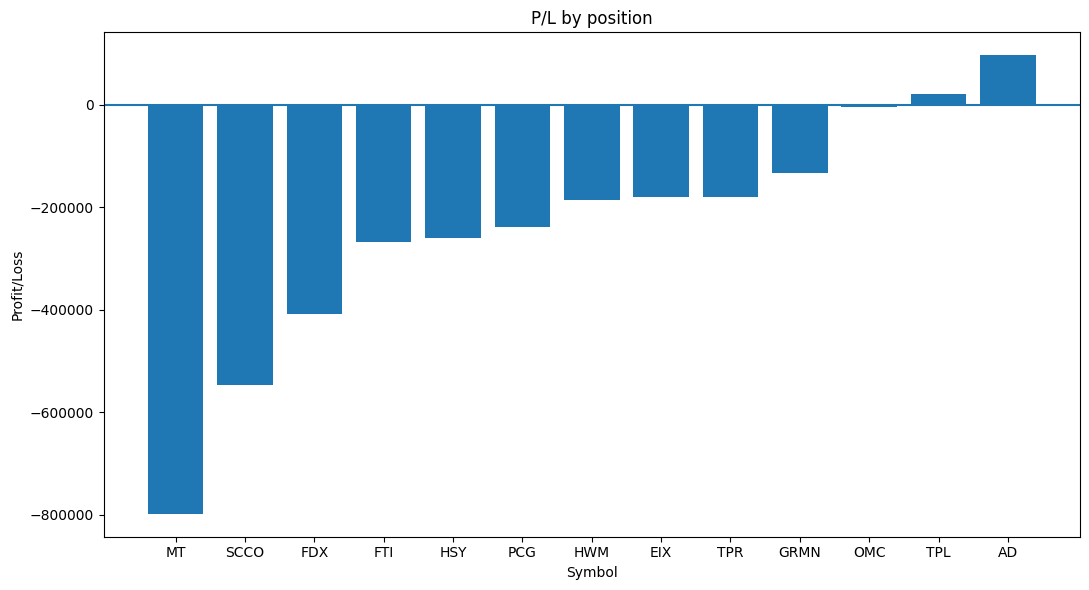

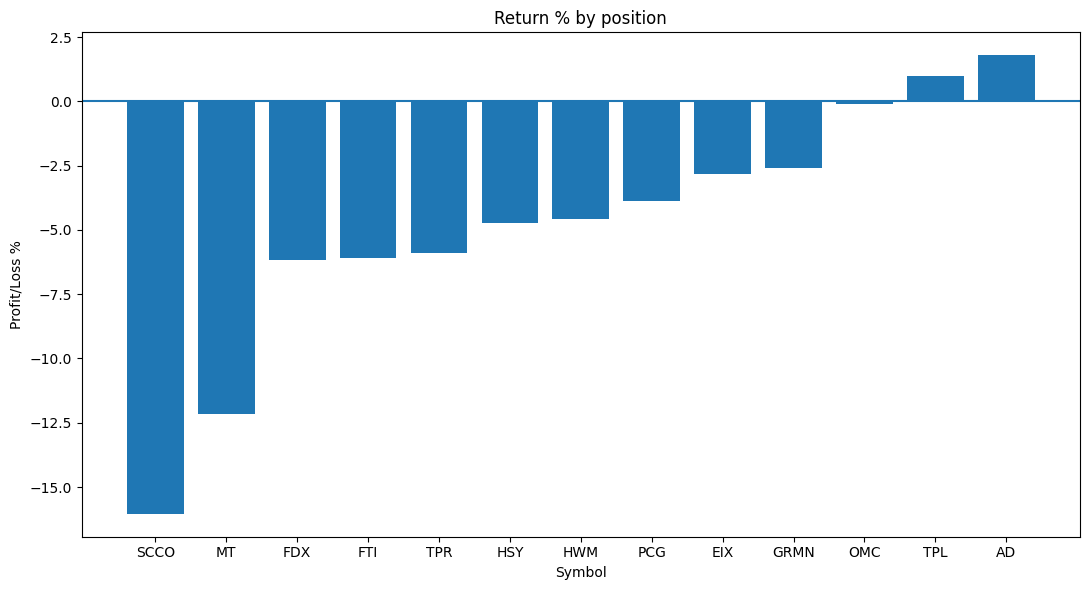

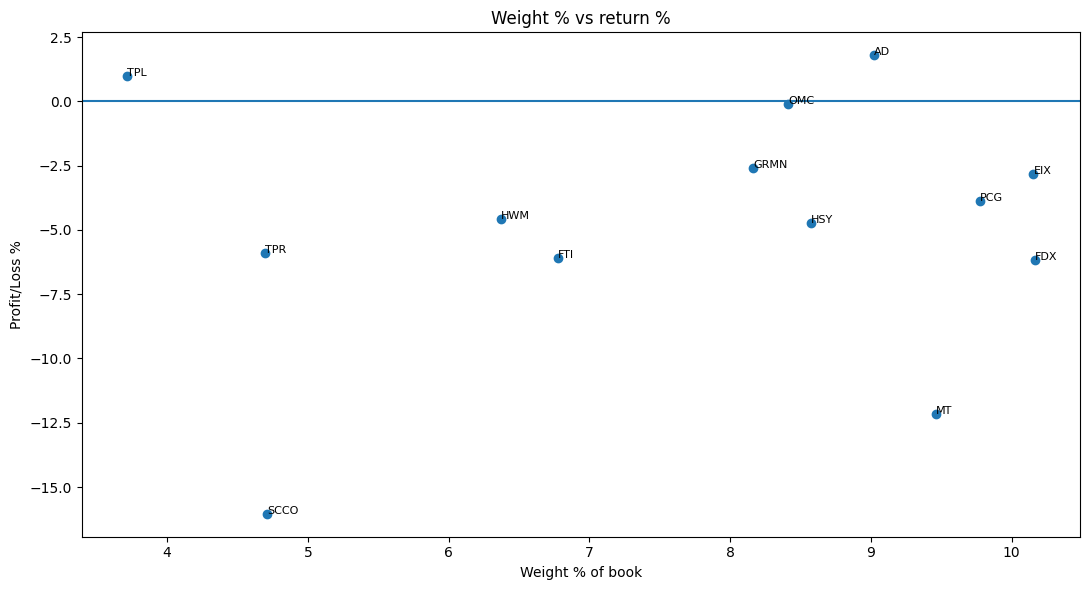

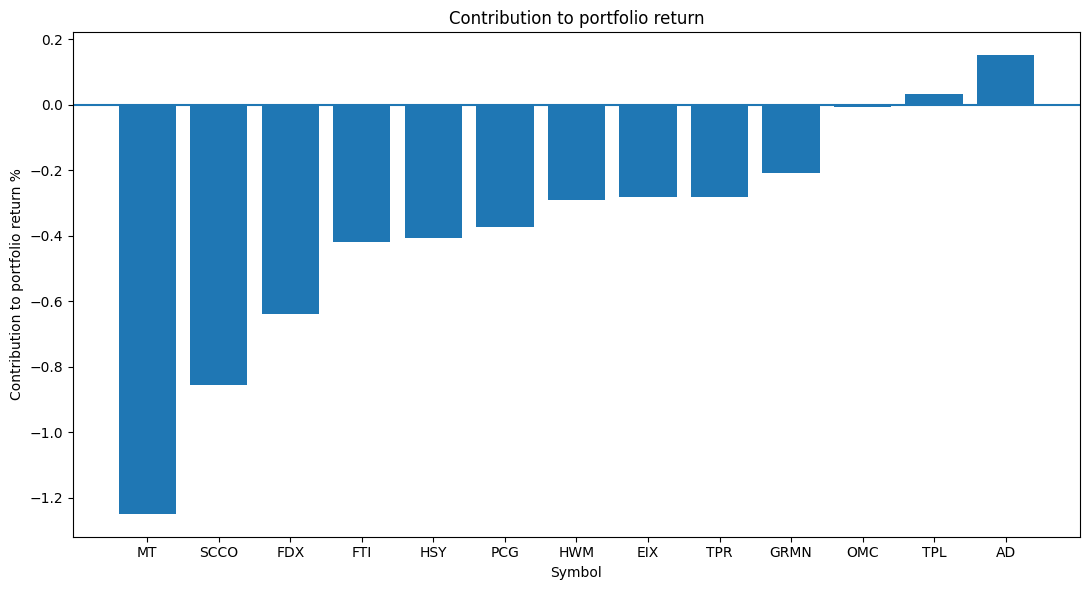

In [6]:
plot_df = detail.sort_values("ProfitLoss")

plt.figure()
plt.bar(plot_df["Symbol"], plot_df["ProfitLoss"])
plt.axhline(0)
plt.title("P/L by position")
plt.xlabel("Symbol")
plt.ylabel("Profit/Loss")
plt.tight_layout()
plt.show()

plot_df = detail.sort_values("ProfitLossPercentage")

plt.figure()
plt.bar(plot_df["Symbol"], plot_df["ProfitLossPercentage"])
plt.axhline(0)
plt.title("Return % by position")
plt.xlabel("Symbol")
plt.ylabel("Profit/Loss %")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(detail["WeightPct"], detail["ProfitLossPercentage"])
for _, row in detail.iterrows():
    plt.annotate(row["Symbol"], (row["WeightPct"], row["ProfitLossPercentage"]), fontsize=8)
plt.axhline(0)
plt.title("Weight % vs return %")
plt.xlabel("Weight % of book")
plt.ylabel("Profit/Loss %")
plt.tight_layout()
plt.show()

plot_df = detail.sort_values("PortfolioReturnContributionPct")

plt.figure()
plt.bar(plot_df["Symbol"], plot_df["PortfolioReturnContributionPct"])
plt.axhline(0)
plt.title("Contribution to portfolio return")
plt.xlabel("Symbol")
plt.ylabel("Contribution to portfolio return %")
plt.tight_layout()
plt.show()


## 4) Europe exit scenario

This is the editable scenario block.  
Start with the names you plan to exit to clean up the book and refocus on the US names.

By default:
- `MT`
- `FTI`

You can add or remove tickers here.


In [7]:
EUROPE_LINKED_TICKERS = ["MT", "FTI"]   # edit this list if needed

df["RegionBucket"] = np.where(df["Symbol"].isin(EUROPE_LINKED_TICKERS), "Europe-linked", "US-focused")

eu = df[df["RegionBucket"] == "Europe-linked"].copy()
us = df[df["RegionBucket"] == "US-focused"].copy()

scenario = pd.DataFrame({
    "Metric": [
        "Europe-linked market value",
        "Europe-linked P/L",
        "Europe-linked weight %",
        "Share of total loss from Europe-linked names %",
        "US-focused market value after exit",
        "US-focused P/L after exit",
        "US-focused return % after exit",
    ],
    "Value": [
        eu["MarketValue"].sum(),
        eu["ProfitLoss"].sum(),
        eu["MarketValue"].sum() / df["MarketValue"].sum() * 100 if len(eu) else 0,
        eu["ProfitLoss"].sum() / df["ProfitLoss"].sum() * 100 if df["ProfitLoss"].sum() != 0 else np.nan,
        us["MarketValue"].sum(),
        us["ProfitLoss"].sum(),
        us["ProfitLoss"].sum() / us["CostBasis"].sum() * 100 if len(us) else np.nan,
    ]
})
scenario


,Metric,Value
0,Europe-linked market value,9.883489e+06
1,Europe-linked P/L,-1.066635e+06
2,Europe-linked weight %,1.624081e+01
3,Share of total loss from Europe-linked names %,3.455984e+01
4,US-focused market value after exit,5.097238e+07
5,US-focused P/L after exit,-2.019708e+06
6,US-focused return % after exit,-3.811339e+00


### How to read this scenario

If a small sleeve of the book explains a disproportionate share of the loss, exiting it often improves the book in two ways:

- the book becomes easier to manage,
- the remaining risk budget can be reallocated only after you decide which US names actually deserve capital.

The key mistake would be to sell Europe and then **automatically average down into the weakest US names**.  
That is not refocusing. That is just moving the same bad habit into a different geography.


,Symbol,Description,MarketValue,USWeightAfterExitPct,ProfitLoss,ProfitLossPercentage,DeskBucket
10,SCCO,Southern Copper Corporation,2.867381e+06,5.625363,-547681.18,-16.04,Hard cut / thesis failed
2,FDX,Fedex Corp,6.185247e+06,12.134507,-408043.75,-6.19,Cut / de-risk now
5,HSY,Hershey Company,5.217505e+06,10.235945,-260423.04,-4.75,Hold only with thesis
9,PCG,PG&E Corp.,5.949619e+06,11.672240,-238901.09,-3.86,Hold only with thesis
6,HWM,Howmet Aerospace Inc,3.877484e+06,7.607028,-185247.38,-4.56,Hold only with thesis
1,EIX,Edison International,6.180080e+06,12.124370,-179993.97,-2.83,Hold only with thesis
12,TPR,Tapestry Inc,2.855316e+06,5.601692,-179460.02,-5.91,Reduce / tight leash
4,GRMN,Garmin Ltd,4.969621e+06,9.749636,-133078.41,-2.61,Hold only with thesis
8,OMC,"Omnicom Group, Inc.",5.120010e+06,10.044675,-4822.80,-0.09,Hold only with thesis
11,TPL,Texas Pacific Land Corporation,2.260819e+06,4.435380,21659.56,0.97,Flat / neutral


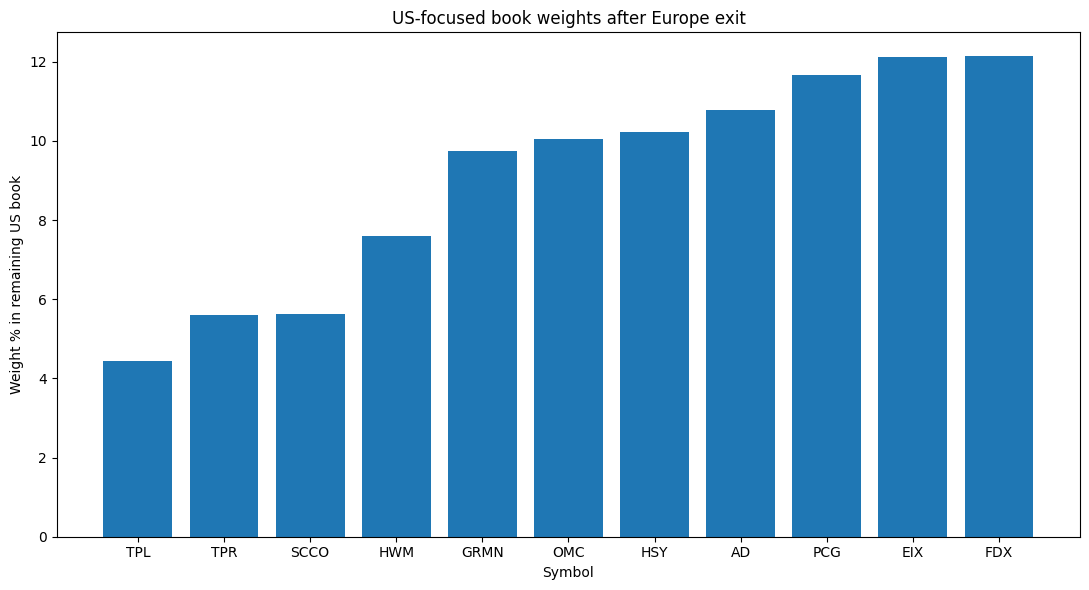

In [8]:
us_detail = us[detail_cols].sort_values("ProfitLoss").copy()
us_detail["USWeightAfterExitPct"] = us_detail["MarketValue"] / us_detail["MarketValue"].sum() * 100

display(us_detail[[
    "Symbol", "Description", "MarketValue", "USWeightAfterExitPct",
    "ProfitLoss", "ProfitLossPercentage", "DeskBucket"
]].sort_values("ProfitLoss"))

plt.figure()
plt.bar(us_detail.sort_values("USWeightAfterExitPct")["Symbol"], us_detail.sort_values("USWeightAfterExitPct")["USWeightAfterExitPct"])
plt.title("US-focused book weights after Europe exit")
plt.xlabel("Symbol")
plt.ylabel("Weight % in remaining US book")
plt.tight_layout()
plt.show()


## 5) Desk action list

This is not a prediction engine. It is a **risk-management triage**.

A PM or trader typically asks:
- which names must leave now,
- which names can stay only with smaller size,
- which names are allowed to earn more capital,
- and what the hard risk limits are after the rebalance.


In [9]:
def desk_action(row, europe_names):
    s = row["Symbol"]
    loss_pct = row["ProfitLossPercentage"]
    weight_pct = row["WeightPct"]

    if s in europe_names:
        return "EXIT Europe-linked sleeve"
    if loss_pct <= -10:
        return "EXIT / thesis broken"
    if loss_pct <= -6 and weight_pct >= 8:
        return "CUT hard"
    if loss_pct <= -5:
        return "REDUCE"
    if loss_pct < 0:
        return "HOLD only if thesis intact"
    if loss_pct >= 1:
        return "KEEP; add only on strength"
    return "HOLD / neutral"

df["DeskAction"] = df.apply(lambda row: desk_action(row, set(EUROPE_LINKED_TICKERS)), axis=1)

action_table = df[[
    "Symbol", "Description", "RegionBucket", "MarketValue", "WeightPct",
    "ProfitLoss", "ProfitLossPercentage", "DeskBucket", "DeskAction"
]].sort_values(["DeskAction", "ProfitLoss"])

action_table


,Symbol,Description,RegionBucket,MarketValue,WeightPct,ProfitLoss,ProfitLossPercentage,DeskBucket,DeskAction
2,FDX,Fedex Corp,US-focused,6.185247e+06,10.163764,-408043.75,-6.19,Cut / de-risk now,CUT hard
10,SCCO,Southern Copper Corporation,US-focused,2.867381e+06,4.711758,-547681.18,-16.04,Hard cut / thesis failed,EXIT / thesis broken
7,MT,ARCELORMITTAL,Europe-linked,5.758682e+06,9.462820,-798280.72,-12.17,Hard cut / thesis failed,EXIT Europe-linked sleeve
3,FTI,TechnipFMC plc,Europe-linked,4.124807e+06,6.777994,-268354.65,-6.11,Reduce / tight leash,EXIT Europe-linked sleeve
11,TPL,Texas Pacific Land Corporation,US-focused,2.260819e+06,3.715038,21659.56,0.97,Flat / neutral,HOLD / neutral
5,HSY,Hershey Company,US-focused,5.217505e+06,8.573544,-260423.04,-4.75,Hold only with thesis,HOLD only if thesis intact
9,PCG,PG&E Corp.,US-focused,5.949619e+06,9.776573,-238901.09,-3.86,Hold only with thesis,HOLD only if thesis intact
6,HWM,Howmet Aerospace Inc,US-focused,3.877484e+06,6.371585,-185247.38,-4.56,Hold only with thesis,HOLD only if thesis intact
1,EIX,Edison International,US-focused,6.180080e+06,10.155273,-179993.97,-2.83,Hold only with thesis,HOLD only if thesis intact
4,GRMN,Garmin Ltd,US-focused,4.969621e+06,8.166215,-133078.41,-2.61,Hold only with thesis,HOLD only if thesis intact


## 6) Proposed way to trade the book after Europe exit

A disciplined US-focused approach would usually look like this:

**First**, remove the sleeve you already decided is not part of the core mandate.  
That is a mandate decision, not a market call.

**Second**, do not recycle the cash mechanically into every remaining loser.  
Give more risk only to names that are:
- near flat or green,
- not already oversized,
- still consistent with the thesis.

**Third**, cap single-name risk.  
A practical rule is to keep most names around a narrow band and stop letting weak names stay large.

**Fourth**, separate three buckets:
- core keeps,
- tactical holds under review,
- forced reductions or exits.

You can edit the risk limits below and rerun the notebook.


In [10]:
MAX_SINGLE_NAME_WEIGHT_PCT = 10.0
MAX_REBUILD_WEIGHT_PCT = 8.0

us_book = us.copy()
us_book["CurrentUSWeightPct"] = us_book["MarketValue"] / us_book["MarketValue"].sum() * 100

def sizing_comment(row):
    w = row["CurrentUSWeightPct"]
    r = row["ProfitLossPercentage"]

    if r > 0 and w < MAX_REBUILD_WEIGHT_PCT:
        return "Candidate to receive capital if thesis still good"
    if r <= 0 and w > MAX_SINGLE_NAME_WEIGHT_PCT:
        return "Too large for a losing name"
    if r <= -5:
        return "Do not add until setup improves"
    return "Neutral sizing"

us_book["SizingComment"] = us_book.apply(sizing_comment, axis=1)

us_book[[
    "Symbol", "Description", "CurrentUSWeightPct", "ProfitLossPercentage",
    "DeskAction", "SizingComment"
]].sort_values(["ProfitLossPercentage", "CurrentUSWeightPct"])


KeyError: "['DeskAction'] not in index"

## 7) My bottom-line read on this snapshot

Based on the current file only:

- the book is not being hurt by one freak position; the weakness is broad,
- some losing names are still meaningful sizes,
- removing the Europe-linked sleeve improves the book, but does **not** solve the US book by itself,
- the next edge is not “find more names”; it is **better triage and tighter sizing discipline**.

A clean operating plan would be:

1. exit the Europe-linked sleeve,
2. cut or reduce the weakest remaining US names,
3. keep only a small number of names that are allowed to earn fresh capital,
4. add only on strength, not on hope,
5. rerun this notebook after each rebalance.

If you later add historical prices, sector/industry mapping, and benchmark returns, this notebook can be extended into a much better PM dashboard.


In [11]:
# Optional export tables if you want to save the outputs
OUT_DIR = Path("desk_review_outputs")
OUT_DIR.mkdir(exist_ok=True)

detail.to_csv(OUT_DIR / "full_position_detail.csv", index=False)
action_table.to_csv(OUT_DIR / "desk_action_table.csv", index=False)
us_book.to_csv(OUT_DIR / "us_book_after_europe_exit.csv", index=False)

print(f"Saved outputs to: {OUT_DIR.resolve()}")


Saved outputs to: /Users/phamthanh/Documents/ESSCA | MSc Finance & Data Analyst/14. ESG Portfolio/v1.5/desk_review_outputs
